# IndiGo Demand Forecasting



Goal:
Forecast future passenger demand, revenue, and profitability using time-series analysis.

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA

import warnings
warnings.filterwarnings("ignore")

In [ ]:
indigo = pd.read_csv(
    "indigo_profitability.csv"
)

indigo.head()

,Airline,Airline_ID,Source_Airport,Source_Airport_ID,Destination_Airport,Destination_Airport_ID,Codeshare,Stops,Equipment,Source_Airport_Name,...,Fuel_Cost,Airport_Charges,Crew_Cost,Maintenance_Cost,Operating_Cost,Profit,Profit_Margin,Flights_Per_Day,Flights_Per_Year,Profit_Category
0,6E,2850.0,AMD,2994.0,BLR,3131.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,...,465798,206299,36256,57658,1397970075,959328405,40.696094,5,1825,High Profit
1,6E,2850.0,AMD,2994.0,BOM,2997.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,...,682238,187050,106256,31852,367699540,1229576960,76.979594,1,365,High Profit
2,6E,2850.0,AMD,2994.0,CCU,3043.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,...,319735,67153,63937,27551,1222250680,450083690,26.913499,7,2555,Medium Profit
3,6E,2850.0,AMD,2994.0,DEL,3093.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,...,355683,109765,31651,96947,1517787530,778103350,33.891129,7,2555,Medium Profit
4,6E,2850.0,AMD,2994.0,GOI,3007.0,NaN,0,320,Sardar Vallabhbhai Patel International Airport,...,736437,158212,80288,86001,2710696590,-971486190,-55.857888,7,2555,Low Profit


In [ ]:
print(indigo.shape)

(199, 36)


In [ ]:
months = pd.date_range(
    start="2022-01-01",
    periods=36,
    freq="M"
)

months

DatetimeIndex(['2022-01-31', '2022-02-28', '2022-03-31', '2022-04-30',
               '2022-05-31', '2022-06-30', '2022-07-31', '2022-08-31',
               '2022-09-30', '2022-10-31', '2022-11-30', '2022-12-31',
               '2023-01-31', '2023-02-28', '2023-03-31', '2023-04-30',
               '2023-05-31', '2023-06-30', '2023-07-31', '2023-08-31',
               '2023-09-30', '2023-10-31', '2023-11-30', '2023-12-31',
               '2024-01-31', '2024-02-29', '2024-03-31', '2024-04-30',
               '2024-05-31', '2024-06-30', '2024-07-31', '2024-08-31',
               '2024-09-30', '2024-10-31', '2024-11-30', '2024-12-31'],
              dtype='datetime64[ns]', freq='ME')

In [ ]:
base_passengers = (
    indigo["Passengers"].sum()
)

print(base_passengers)

32389


In [ ]:
np.random.seed(42)

np.random.seed(42)

demand = pd.DataFrame({
    "Month": months
})

trend = np.linspace(1.0, 1.40, 36)

seasonality = (
    1
    + 0.08*np.sin(
        np.arange(36)*2*np.pi/12
    )
)

noise = np.random.normal(
    1,
    0.02,
    36
)

demand["Passengers"] = (
    base_passengers
    * trend
    * seasonality
    * noise
)

In [ ]:
demand.head()

,Month,Passengers
0,2022-01-31,32710.761494
1,2022-02-28,33975.314415
2,2022-03-31,35883.468593
3,2022-04-30,37281.485697
4,2022-05-31,36046.594595


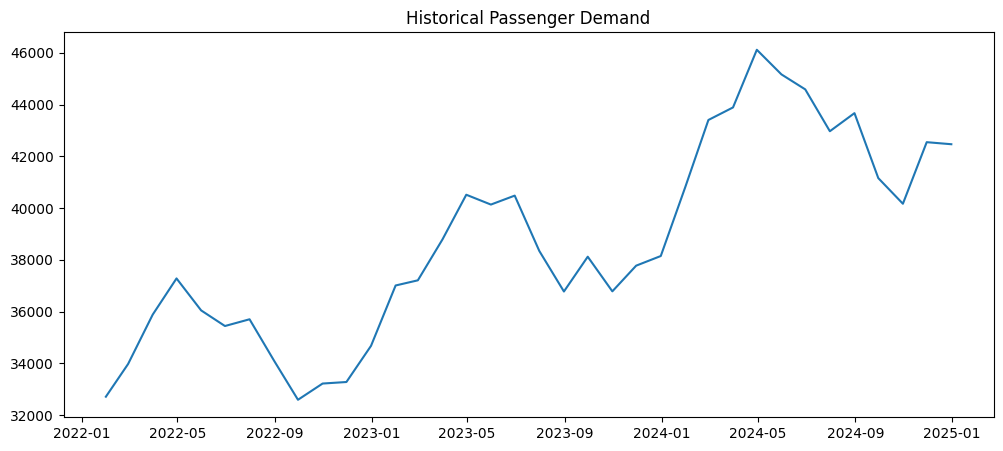

In [ ]:
plt.figure(figsize=(12,5))

plt.plot(
    demand["Month"],
    demand["Passengers"]
)

plt.title(
    "Historical Passenger Demand"
)

plt.show()

In [ ]:
avg_ticket = (
    indigo["Avg_Ticket_Price"]
    .mean()
)

demand["Revenue"] = (
    demand["Passengers"]
    *
    avg_ticket
)

In [ ]:
company_margin = (
    indigo["Profit"].sum()
    /
    indigo["Revenue"].sum()
)

company_margin

np.float64(0.25815130468214265)

In [ ]:
demand["Profit"] = (
    demand["Revenue"]
    *
    company_margin
)

In [ ]:
demand.head()

,Month,Passengers,Revenue,Profit
0,2022-01-31,32710.761494,2.401290e+08,6.198963e+07
1,2022-02-28,33975.314415,2.494121e+08,6.438606e+07
2,2022-03-31,35883.468593,2.634198e+08,6.800217e+07
3,2022-04-30,37281.485697,2.736826e+08,7.065153e+07
4,2022-05-31,36046.594595,2.646173e+08,6.831131e+07


In [ ]:
model = ARIMA(
    demand["Passengers"],
    order=(2,1,2)
)

model_fit = model.fit()

In [ ]:
forecast_passengers = model_fit.forecast(
    steps=12
)

forecast_passengers

,predicted_mean
36,43629.788922
37,44812.936989
38,45694.855312
39,46039.585276
40,45760.775574
41,44943.101324
42,43816.805276
43,42692.951971
44,41877.578704
45,41588.419463


In [ ]:
future_dates = pd.date_range(
    start=demand["Month"].max(),
    periods=13,
    freq="M"
)[1:]

In [ ]:
forecast_df = pd.DataFrame({
    "Month": future_dates,
    "Forecast_Passengers":
    forecast_passengers
})

In [ ]:
forecast_df.head()

,Month,Forecast_Passengers
36,2025-01-31,43629.788922
37,2025-02-28,44812.936989
38,2025-03-31,45694.855312
39,2025-04-30,46039.585276
40,2025-05-31,45760.775574


In [ ]:
forecast_df["Forecast_Revenue"] = (
    forecast_df["Forecast_Passengers"]
    *
    avg_ticket
)

In [ ]:
forecast_df["Forecast_Profit"] = (
    forecast_df["Forecast_Revenue"]
    *
    company_margin
)

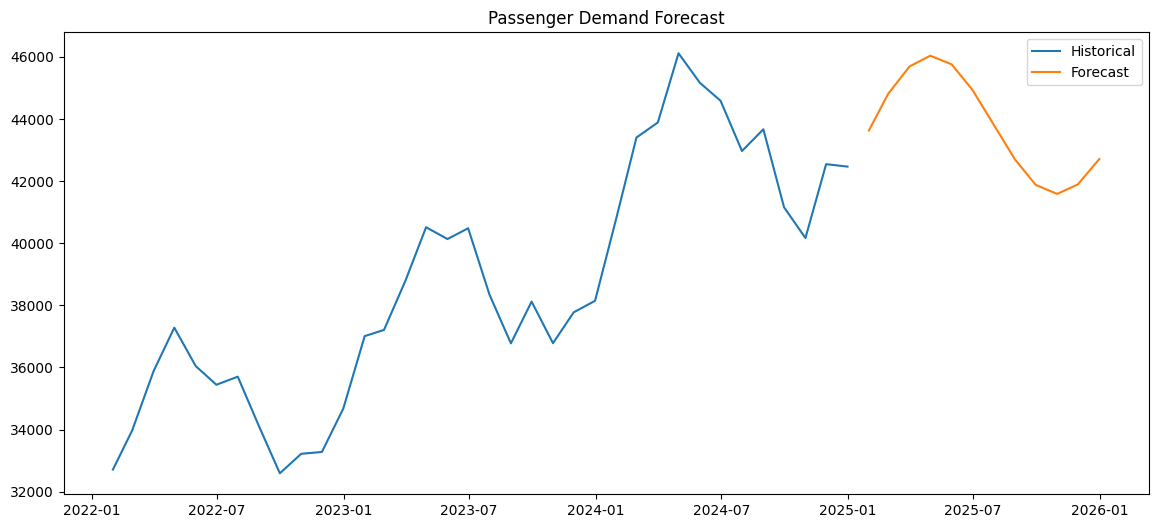

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    demand["Month"],
    demand["Passengers"],
    label="Historical"
)

plt.plot(
    forecast_df["Month"],
    forecast_df["Forecast_Passengers"],
    label="Forecast"
)

plt.legend()

plt.title(
    "Passenger Demand Forecast"
)

plt.show()

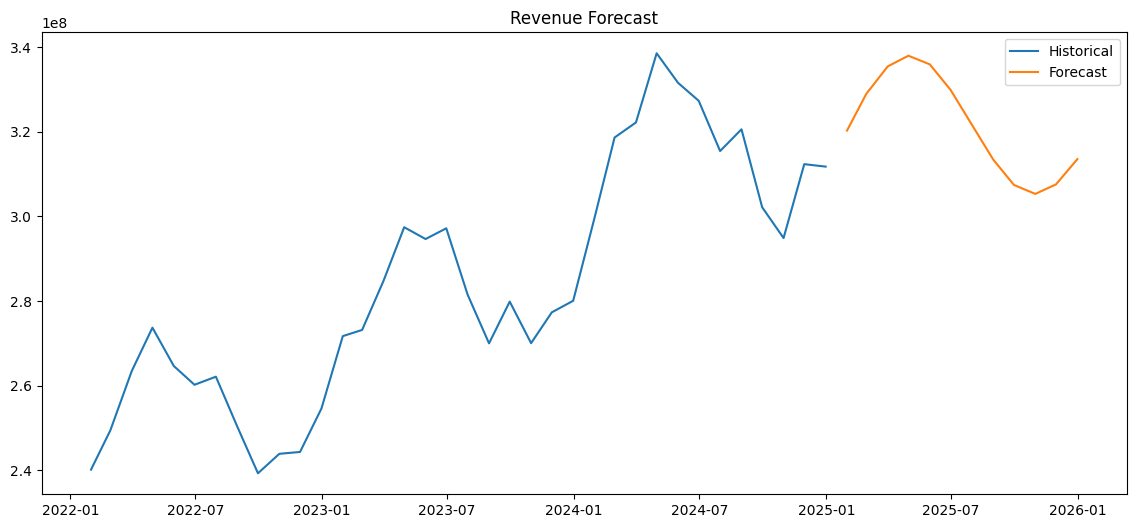

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    demand["Month"],
    demand["Revenue"],
    label="Historical"
)

plt.plot(
    forecast_df["Month"],
    forecast_df["Forecast_Revenue"],
    label="Forecast"
)

plt.legend()

plt.title(
    "Revenue Forecast"
)

plt.show()

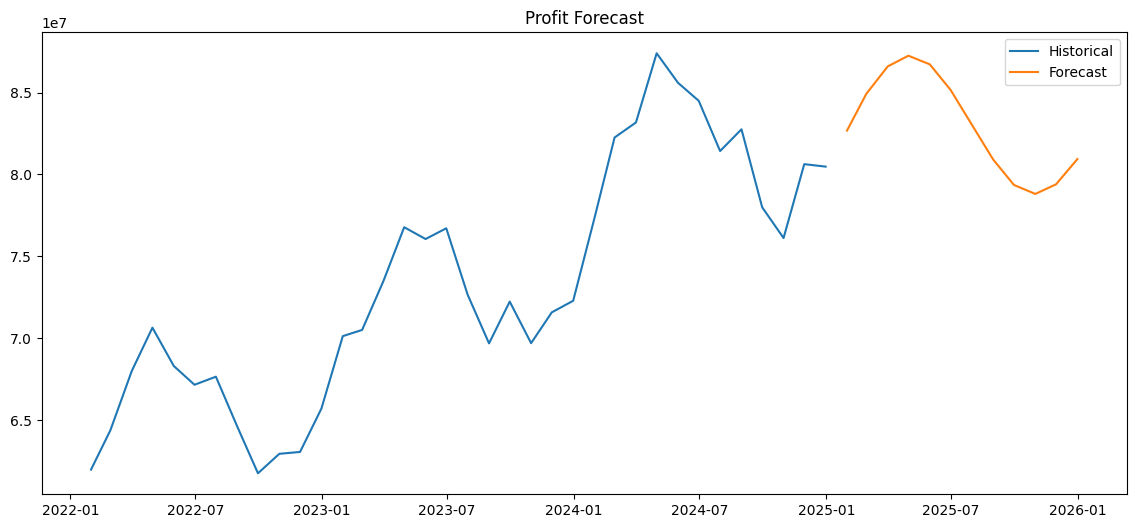

In [ ]:
plt.figure(figsize=(14,6))

plt.plot(
    demand["Month"],
    demand["Profit"],
    label="Historical"
)

plt.plot(
    forecast_df["Month"],
    forecast_df["Forecast_Profit"],
    label="Forecast"
)

plt.legend()

plt.title(
    "Profit Forecast"
)

plt.show()

In [ ]:
forecast_df.head(6)

,Month,Forecast_Passengers,Forecast_Revenue,Forecast_Profit
36,2025-01-31,43629.788922,3.202854e+08,8.268209e+07
37,2025-02-28,44812.936989,3.289709e+08,8.492426e+07
38,2025-03-31,45694.855312,3.354450e+08,8.659557e+07
39,2025-04-30,46039.585276,3.379757e+08,8.724886e+07
40,2025-05-31,45760.775574,3.359289e+08,8.672049e+07
41,2025-06-30,44943.101324,3.299264e+08,8.517093e+07


In [ ]:
forecast_df

,Month,Forecast_Passengers,Forecast_Revenue,Forecast_Profit
36,2025-01-31,43629.788922,3.202854e+08,8.268209e+07
37,2025-02-28,44812.936989,3.289709e+08,8.492426e+07
38,2025-03-31,45694.855312,3.354450e+08,8.659557e+07
39,2025-04-30,46039.585276,3.379757e+08,8.724886e+07
40,2025-05-31,45760.775574,3.359289e+08,8.672049e+07
41,2025-06-30,44943.101324,3.299264e+08,8.517093e+07
42,2025-07-31,43816.805276,3.216583e+08,8.303651e+07
43,2025-08-31,42692.951971,3.134081e+08,8.090671e+07
44,2025-09-30,41877.578704,3.074225e+08,7.936151e+07
45,2025-10-31,41588.419463,3.052998e+08,7.881353e+07


In [ ]:
current_passengers = (
    demand["Passengers"].iloc[-1]
)

future_passengers = (
    forecast_df["Forecast_Passengers"].iloc[-1]
)

growth = (
    (
        future_passengers
        -
        current_passengers
    )
    /
    current_passengers
) * 100

growth

np.float64(0.5711359625491683)

In [ ]:
print(
    f"Expected Passenger Growth: {growth:.2f}%"
)

Expected Passenger Growth: 0.57%


In [ ]:
forecast_summary = pd.DataFrame({

    "Metric":[
        "Passengers",
        "Revenue",
        "Profit"
    ],

    "Current":[
        demand["Passengers"].iloc[-1],
        demand["Revenue"].iloc[-1],
        demand["Profit"].iloc[-1]
    ],

    "Forecast_12M":[
        forecast_df["Forecast_Passengers"].iloc[-1],
        forecast_df["Forecast_Revenue"].iloc[-1],
        forecast_df["Forecast_Profit"].iloc[-1]
    ]
})

forecast_summary

,Metric,Current,Forecast_12M
0,Passengers,4.246793e+04,4.271048e+04
1,Revenue,3.117562e+08,3.135368e+08
2,Profit,8.048027e+07,8.093993e+07


In [ ]:
forecast_df.to_csv(
    "indigo_forecast.csv",
    index=False
)

print("Forecast File Saved")

Forecast File Saved


In [ ]:
print("="*60)

print("INDIGO DEMAND FORECAST REPORT")

print("="*60)

print(
    "Historical Months:",
    len(demand)
)

print(
    "Forecast Months:",
    len(forecast_df)
)

print()

print(
    "Current Monthly Passengers:",
    round(
        demand["Passengers"].iloc[-1]
    )
)

print(
    "Forecast Monthly Passengers:",
    round(
        forecast_df["Forecast_Passengers"].iloc[-1]
    )
)

print()

print(
    "Expected Growth:",
    round(growth,2),
    "%"
)

print("="*60)

INDIGO DEMAND FORECAST REPORT
Historical Months: 36
Forecast Months: 12

Current Monthly Passengers: 42468
Forecast Monthly Passengers: 42710

Expected Growth: 0.57 %
